In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import json
import joblib

from src.models.advanced_clustering import (
    AdvancedClustering,
    profile_segments,
    assign_business_labels,
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

np.random.seed(42)

Path('../reports').mkdir(parents=True, exist_ok=True)
Path('../reports/figures').mkdir(parents=True, exist_ok=True)
Path('../data/processed').mkdir(parents=True, exist_ok=True)
Path('../models').mkdir(parents=True, exist_ok=True)

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
input_path = Path('../data/processed/customer_segments.csv')

if input_path.exists():
    customer_data = pd.read_csv(input_path)
    print("Loaded customer_segments.csv from Part 5")
else:
    customer_data = pd.read_csv('../data/processed/customer_features.csv')
    print("customer_segments.csv not found. Loaded customer_features.csv instead.")

for col in ['First_Purchase', 'Last_Purchase']:
    if col in customer_data.columns:
        customer_data[col] = pd.to_datetime(customer_data[col])

print(f"Customers loaded: {len(customer_data):,}")
print(f"Columns: {len(customer_data.columns)}")

customer_data.head()

Loaded customer_segments.csv from Part 5
Customers loaded: 4,312
Columns: 21


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Total_Items,Total_Orders,Avg_Order_Value,Unique_Products,First_Purchase,Last_Purchase,Avg_Items_Per_Order,Customer_Lifespan_Days,Purchase_Frequency,Segment_Preview,Cluster,Segment
0,12346.00,165,11,372.86,2,5,2,252,9,70,11,11.30,26,2009-12-14 08:34:00,2010-06-28 13:53:00,6.36,196,0.06,Medium Value,1,Lost/Low Value
1,12347.00,3,2,1323.32,5,2,4,524,11,828,2,18.64,70,2010-10-31 14:20:00,2010-12-07 14:57:00,414.00,37,0.05,High Value,0,At Risk
2,12348.00,74,1,222.16,2,1,1,211,4,373,1,11.11,20,2010-09-27 14:59:00,2010-09-27 14:59:00,373.00,0,1.00,Low Value,0,At Risk
3,12349.00,43,3,2671.14,3,3,5,335,11,993,3,26.19,90,2010-04-29 13:20:00,2010-10-28 08:23:00,331.00,181,0.02,High Value,0,At Risk
4,12351.00,11,1,300.93,5,1,2,512,8,261,1,14.33,21,2010-11-29 15:23:00,2010-11-29 15:23:00,261.00,0,1.00,Medium Value,0,At Risk


In [3]:
candidate_features = [
    'Recency',
    'Frequency',
    'Monetary',
    'Avg_Order_Value',
    'Unique_Products',
    'Avg_Items_Per_Order',
    'Customer_Lifespan_Days',
    'Purchase_Frequency',
]

feature_cols = [col for col in candidate_features if col in customer_data.columns]
missing_features = [col for col in candidate_features if col not in customer_data.columns]

print("Advanced clustering features:")
for col in feature_cols:
    print(f"  - {col}")

if missing_features:
    print("\nMissing optional features:")
    for col in missing_features:
        print(f"  - {col}")

print(f"\nTotal features used: {len(feature_cols)}")

Advanced clustering features:
  - Recency
  - Frequency
  - Monetary
  - Avg_Order_Value
  - Unique_Products
  - Avg_Items_Per_Order
  - Customer_Lifespan_Days
  - Purchase_Frequency

Total features used: 8


In [4]:
print("Feature summary before transformation:\n")

feature_summary = customer_data[feature_cols].describe().T
feature_summary['skewness'] = customer_data[feature_cols].skew()

feature_summary

Feature summary before transformation:



,count,mean,std,min,25%,50%,75%,max,skewness
Recency,4312.00,91.17,96.86,1.00,18.00,53.00,136.00,374.00,1.28
Frequency,4312.00,4.46,8.17,1.00,1.00,2.00,5.00,205.00,10.55
Monetary,4312.00,2040.41,8911.76,2.95,307.19,701.62,1714.93,349164.35,24.00
Avg_Order_Value,4312.00,37.01,217.72,1.99,11.19,17.36,24.84,10953.50,37.82
Unique_Products,4312.00,63.65,85.76,1.00,17.00,38.00,79.25,1741.00,6.15
Avg_Items_Per_Order,4312.00,254.62,1554.08,1.00,89.00,150.89,255.05,87167.00,46.46
Customer_Lifespan_Days,4312.00,134.00,132.83,0.00,0.00,105.00,254.00,373.00,0.42
Purchase_Frequency,4312.00,0.40,0.52,0.01,0.02,0.04,1.00,4.00,1.29


In [5]:
log_transform_cols = [
    col for col in feature_cols
    if col in [
        'Recency',
        'Frequency',
        'Monetary',
        'Avg_Order_Value',
        'Unique_Products',
        'Avg_Items_Per_Order',
        'Customer_Lifespan_Days',
        'Purchase_Frequency',
    ]
]

advanced_clusterer = AdvancedClustering(random_state=42, scaler_type='robust')

X_scaled = advanced_clusterer.prepare_features(
    customer_data,
    feature_cols=feature_cols,
    log_transform_cols=log_transform_cols,
)

print(f"Prepared feature matrix: {X_scaled.shape}")
print(f"Scaler used: {advanced_clusterer.scaler_type}")
print(f"Log-transformed columns: {log_transform_cols}")

scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
scaled_df.head()

Prepared feature matrix: (4312, 8)
Scaler used: robust
Log-transformed columns: ['Recency', 'Frequency', 'Monetary', 'Avg_Order_Value', 'Unique_Products', 'Avg_Items_Per_Order', 'Customer_Lifespan_Days', 'Purchase_Frequency']


,Recency,Frequency,Monetary,Avg_Order_Value,Unique_Products,Avg_Items_Per_Order,Customer_Lifespan_Days,Purchase_Frequency
0,0.57,1.26,-0.37,-0.53,-0.25,-2.89,0.11,0.02
1,-1.32,0.00,0.37,0.09,0.40,0.96,-0.19,0.01
2,0.17,-0.37,-0.67,-0.55,-0.41,0.86,-0.84,0.97
3,-0.10,0.26,0.78,0.52,0.57,0.75,0.10,-0.04
4,-0.76,-0.37,-0.49,-0.24,-0.38,0.52,-0.84,0.97


PCA explained variance:
  PC1: 41.72%
  PC2: 32.02%
  Total: 73.74%


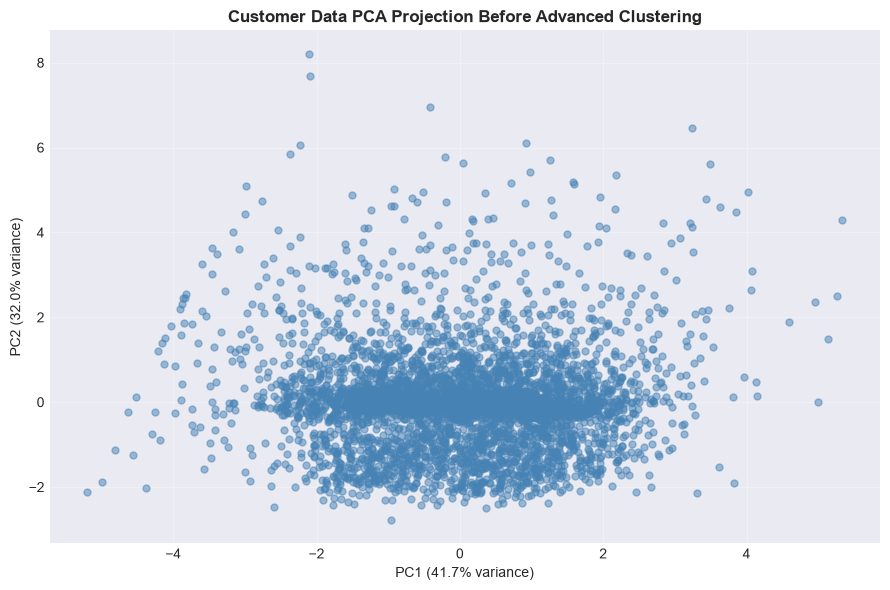

In [6]:
X_pca, pca_model = advanced_clusterer.get_pca_projection(X_scaled, n_components=2)

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
})

explained_variance = pca_model.explained_variance_ratio_

print("PCA explained variance:")
print(f"  PC1: {explained_variance[0] * 100:.2f}%")
print(f"  PC2: {explained_variance[1] * 100:.2f}%")
print(f"  Total: {explained_variance.sum() * 100:.2f}%")

plt.figure(figsize=(9, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.5, s=25, color='steelblue')
plt.xlabel(f"PC1 ({explained_variance[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained_variance[1] * 100:.1f}% variance)")
plt.title("Customer Data PCA Projection Before Advanced Clustering", fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/advanced_pca_before_clustering.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
comparison_df = advanced_clusterer.compare_algorithms(
    X_scaled,
    k_range=range(3, 9),
    include_dbscan=True,
)

comparison_df = comparison_df.sort_values(
    by=['silhouette', 'calinski_harabasz'],
    ascending=[False, False],
)

print("Advanced clustering comparison:")
comparison_df.head(20)

Advanced clustering comparison:


,n_clusters,n_noise,silhouette,calinski_harabasz,davies_bouldin,min_cluster_size,min_cluster_pct,algorithm,k,inertia,bic,aic,eps,min_samples
22,2,155,0.52,111.69,0.47,15.00,0.35,dbscan,NaN,NaN,NaN,NaN,1.00,10.00
19,2,1923,0.40,1924.90,1.03,954.00,22.12,dbscan,NaN,NaN,NaN,NaN,0.50,20.00
20,3,407,0.38,60.59,0.54,6.00,0.14,dbscan,NaN,NaN,NaN,NaN,0.75,10.00
0,3,0,0.28,1448.55,1.25,422.00,9.79,kmeans,3.00,11647.42,NaN,NaN,NaN,NaN
3,4,0,0.25,1299.10,1.32,426.00,9.88,kmeans,4.00,10226.64,NaN,NaN,NaN,NaN
15,8,0,0.23,1106.52,1.22,162.00,3.76,kmeans,8.00,6957.45,NaN,NaN,NaN,NaN
12,7,0,0.23,1151.75,1.21,199.00,4.62,kmeans,7.00,7476.63,NaN,NaN,NaN,NaN
9,6,0,0.22,1198.45,1.25,232.00,5.38,kmeans,6.00,8144.45,NaN,NaN,NaN,NaN
6,5,0,0.22,1249.86,1.36,341.00,7.91,kmeans,5.00,9014.50,NaN,NaN,NaN,NaN
2,3,0,0.20,1011.36,1.36,375.00,8.70,agglomerative,3.00,NaN,NaN,NaN,NaN,NaN


In [8]:
comparison_df.to_csv('../data/processed/advanced_clustering_comparison.csv', index=False)

print("Saved algorithm comparison to:")
print("  - data/processed/advanced_clustering_comparison.csv")

Saved algorithm comparison to:
  - data/processed/advanced_clustering_comparison.csv


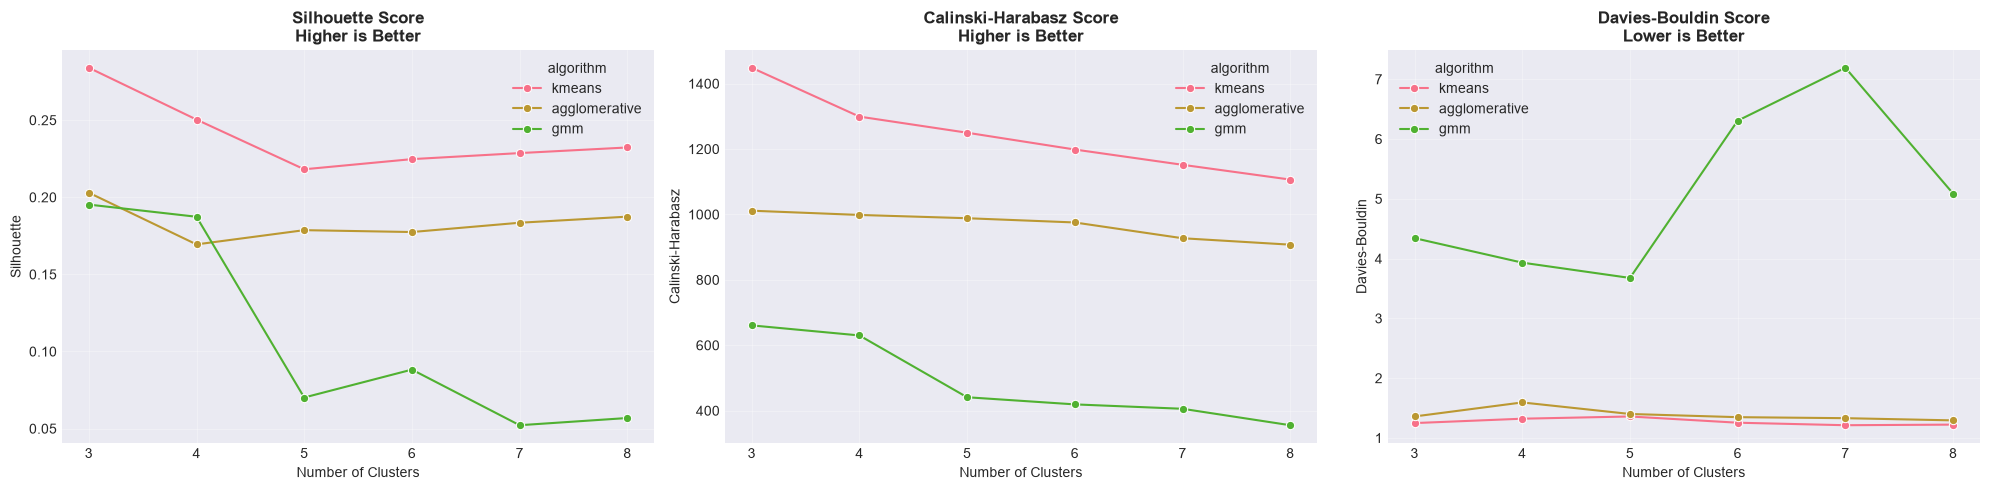

In [9]:
plot_df = comparison_df[
    comparison_df['algorithm'].isin(['kmeans', 'gmm', 'agglomerative'])
].copy()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.lineplot(
    data=plot_df,
    x='k',
    y='silhouette',
    hue='algorithm',
    marker='o',
    ax=axes[0],
)
axes[0].set_title('Silhouette Score\nHigher is Better', fontweight='bold')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Silhouette')
axes[0].grid(alpha=0.3)

sns.lineplot(
    data=plot_df,
    x='k',
    y='calinski_harabasz',
    hue='algorithm',
    marker='o',
    ax=axes[1],
)
axes[1].set_title('Calinski-Harabasz Score\nHigher is Better', fontweight='bold')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Calinski-Harabasz')
axes[1].grid(alpha=0.3)

sns.lineplot(
    data=plot_df,
    x='k',
    y='davies_bouldin',
    hue='algorithm',
    marker='o',
    ax=axes[2],
)
axes[2].set_title('Davies-Bouldin Score\nLower is Better', fontweight='bold')
axes[2].set_xlabel('Number of Clusters')
axes[2].set_ylabel('Davies-Bouldin')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/advanced_algorithm_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
print("Top algorithm/k combinations by silhouette score:\n")

display_cols = [
    'algorithm',
    'k',
    'eps',
    'min_samples',
    'n_clusters',
    'n_noise',
    'silhouette',
    'calinski_harabasz',
    'davies_bouldin',
    'min_cluster_pct',
    'inertia',
    'bic',
    'aic',
]

comparison_df[display_cols].head(15)

Top algorithm/k combinations by silhouette score:



,algorithm,k,eps,min_samples,n_clusters,n_noise,silhouette,calinski_harabasz,davies_bouldin,min_cluster_pct,inertia,bic,aic
22,dbscan,NaN,1.00,10.00,2,155,0.52,111.69,0.47,0.35,NaN,NaN,NaN
19,dbscan,NaN,0.50,20.00,2,1923,0.40,1924.90,1.03,22.12,NaN,NaN,NaN
20,dbscan,NaN,0.75,10.00,3,407,0.38,60.59,0.54,0.14,NaN,NaN,NaN
0,kmeans,3.00,NaN,NaN,3,0,0.28,1448.55,1.25,9.79,11647.42,NaN,NaN
3,kmeans,4.00,NaN,NaN,4,0,0.25,1299.10,1.32,9.88,10226.64,NaN,NaN
15,kmeans,8.00,NaN,NaN,8,0,0.23,1106.52,1.22,3.76,6957.45,NaN,NaN
12,kmeans,7.00,NaN,NaN,7,0,0.23,1151.75,1.21,4.62,7476.63,NaN,NaN
9,kmeans,6.00,NaN,NaN,6,0,0.22,1198.45,1.25,5.38,8144.45,NaN,NaN
6,kmeans,5.00,NaN,NaN,5,0,0.22,1249.86,1.36,7.91,9014.50,NaN,NaN
2,agglomerative,3.00,NaN,NaN,3,0,0.20,1011.36,1.36,8.70,NaN,NaN,NaN


In [11]:
# Final model choice:
# We use K-Means with k=5 for business interpretability and deployment simplicity.
# The comparison above helps validate whether this is reasonable.

FINAL_ALGORITHM = 'kmeans'
FINAL_K = 5

final_model, advanced_labels = advanced_clusterer.fit_predict(
    X_scaled,
    algorithm=FINAL_ALGORITHM,
    n_clusters=FINAL_K,
)

final_metrics = advanced_clusterer.evaluate_labels(X_scaled, advanced_labels)

print(f"Final advanced clustering model: {FINAL_ALGORITHM}")
print(f"Final k: {FINAL_K}")

print("\nFinal model metrics:")
for key, value in final_metrics.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.3f}")
    else:
        print(f"  {key}: {value}")

print("\nCluster sizes:")
pd.Series(advanced_labels).value_counts().sort_index()

Final advanced clustering model: kmeans
Final k: 5

Final model metrics:
  n_clusters: 5
  n_noise: 0
  silhouette: 0.218
  calinski_harabasz: 1249.862
  davies_bouldin: 1.358
  min_cluster_size: 341
  min_cluster_pct: 7.908

Cluster sizes:


0     428
1    1020
2    1112
3     341
4    1411
Name: count, dtype: int64

In [12]:
customer_advanced = customer_data.copy()
customer_advanced['Advanced_Cluster'] = advanced_labels

advanced_cluster_profile = profile_segments(
    customer_advanced,
    segment_col='Advanced_Cluster',
    customer_col='Customer ID',
)

print("Advanced cluster profile:\n")
advanced_cluster_profile

Advanced cluster profile:



,Count,Avg_Recency,Median_Recency,Avg_Frequency,Median_Frequency,Avg_Monetary,Median_Monetary,Total_Revenue,Avg_Order_Value,Avg_Unique_Products,Avg_Items_Per_Order,Avg_Customer_Lifespan_Days,Avg_Purchase_Frequency,Customer_Share_%,Revenue_Share_%
Advanced_Cluster,,,,,,,,,,,,,,,
0,428,163.82,158.00,1.47,1.00,173.48,131.20,74249.61,44.72,5.65,39.49,33.56,0.79,9.90,0.80
1,1020,26.63,15.00,10.72,7.00,5134.41,2768.96,5237096.77,21.50,149.08,280.15,272.22,0.04,23.70,59.50
2,1112,144.14,107.00,1.08,1.00,356.81,294.09,396770.11,14.84,27.97,211.60,0.14,1.05,25.80,4.50
3,341,87.65,57.00,5.23,3.00,5640.79,1567.79,1923509.50,234.34,22.07,1008.70,154.25,0.33,7.90,21.90
4,1411,74.90,52.00,3.31,3.00,826.80,750.56,1166607.75,15.66,57.64,153.09,165.15,0.04,32.70,13.30


In [13]:
try:
    centers_original = advanced_clusterer.inverse_transform_centers()
    print("Advanced cluster centers in original feature scale:\n")
    display(centers_original.round(2))
except ValueError as e:
    print(e)
    centers_original = None

Advanced cluster centers in original feature scale:



,Recency,Frequency,Monetary,Avg_Order_Value,Unique_Products,Avg_Items_Per_Order,Customer_Lifespan_Days,Purchase_Frequency
Cluster,,,,,,,,
0,110.74,1.35,125.34,28.13,4.55,27.18,2.26,0.71
1,14.60,8.07,3262.96,18.39,119.85,231.89,243.60,0.04
2,92.84,1.06,290.12,12.79,22.85,164.21,0.02,1.04
3,48.08,3.49,1857.21,117.64,11.74,306.96,42.77,0.25
4,45.86,3.07,726.60,13.58,46.46,128.73,124.26,0.04


In [14]:
advanced_cluster_labels = assign_business_labels(advanced_cluster_profile)

print("Assigned business labels:\n")

for cluster, label in sorted(advanced_cluster_labels.items()):
    row = advanced_cluster_profile.loc[cluster]

    print(f"Cluster {cluster} -> {label}")
    print(f"  Customers: {int(row['Count']):,}")

    if 'Avg_Recency' in row:
        print(f"  Avg Recency: {row['Avg_Recency']:.1f} days")

    if 'Avg_Frequency' in row:
        print(f"  Avg Frequency: {row['Avg_Frequency']:.1f} orders")

    if 'Avg_Monetary' in row:
        print(f"  Avg Monetary: £{row['Avg_Monetary']:.2f}")

    if 'Revenue_Share_%' in row:
        print(f"  Revenue Share: {row['Revenue_Share_%']:.1f}%")

    print()

Assigned business labels:

Cluster 0 -> Hibernating / Low Value
  Customers: 428
  Avg Recency: 163.8 days
  Avg Frequency: 1.5 orders
  Avg Monetary: £173.48
  Revenue Share: 0.8%

Cluster 1 -> Champions
  Customers: 1,020
  Avg Recency: 26.6 days
  Avg Frequency: 10.7 orders
  Avg Monetary: £5134.41
  Revenue Share: 59.5%

Cluster 2 -> At Risk
  Customers: 1,112
  Avg Recency: 144.1 days
  Avg Frequency: 1.1 orders
  Avg Monetary: £356.81
  Revenue Share: 4.5%

Cluster 3 -> Potential Loyalists
  Customers: 341
  Avg Recency: 87.7 days
  Avg Frequency: 5.2 orders
  Avg Monetary: £5640.79
  Revenue Share: 21.9%

Cluster 4 -> Loyal High Value
  Customers: 1,411
  Avg Recency: 74.9 days
  Avg Frequency: 3.3 orders
  Avg Monetary: £826.80
  Revenue Share: 13.3%



In [15]:
customer_advanced['Advanced_Segment'] = customer_advanced['Advanced_Cluster'].map(
    advanced_cluster_labels
)

advanced_segment_profile = profile_segments(
    customer_advanced,
    segment_col='Advanced_Segment',
    customer_col='Customer ID',
)

print("Advanced segment profile:\n")
advanced_segment_profile

Advanced segment profile:



,Count,Avg_Recency,Median_Recency,Avg_Frequency,Median_Frequency,Avg_Monetary,Median_Monetary,Total_Revenue,Avg_Order_Value,Avg_Unique_Products,Avg_Items_Per_Order,Avg_Customer_Lifespan_Days,Avg_Purchase_Frequency,Customer_Share_%,Revenue_Share_%
Advanced_Segment,,,,,,,,,,,,,,,
At Risk,1112,144.14,107.00,1.08,1.00,356.81,294.09,396770.11,14.84,27.97,211.60,0.14,1.05,25.80,4.50
Champions,1020,26.63,15.00,10.72,7.00,5134.41,2768.96,5237096.77,21.50,149.08,280.15,272.22,0.04,23.70,59.50
Hibernating / Low Value,428,163.82,158.00,1.47,1.00,173.48,131.20,74249.61,44.72,5.65,39.49,33.56,0.79,9.90,0.80
Loyal High Value,1411,74.90,52.00,3.31,3.00,826.80,750.56,1166607.75,15.66,57.64,153.09,165.15,0.04,32.70,13.30
Potential Loyalists,341,87.65,57.00,5.23,3.00,5640.79,1567.79,1923509.50,234.34,22.07,1008.70,154.25,0.33,7.90,21.90


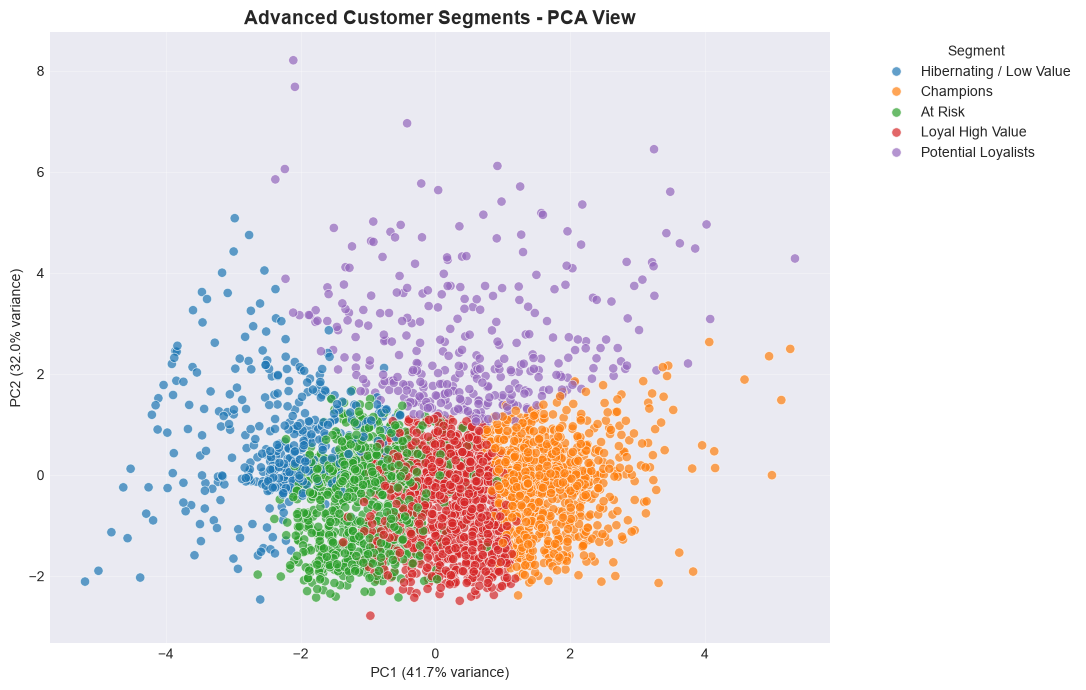

In [16]:
pca_plot_df = pca_df.copy()
pca_plot_df['Advanced_Cluster'] = advanced_labels
pca_plot_df['Advanced_Segment'] = customer_advanced['Advanced_Segment'].values

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=pca_plot_df,
    x='PC1',
    y='PC2',
    hue='Advanced_Segment',
    palette='tab10',
    alpha=0.7,
    s=45,
)

plt.xlabel(f"PC1 ({explained_variance[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained_variance[1] * 100:.1f}% variance)")
plt.title("Advanced Customer Segments - PCA View", fontweight='bold', fontsize=14)
plt.legend(title='Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/advanced_pca_segments.png', dpi=300, bbox_inches='tight')
plt.show()

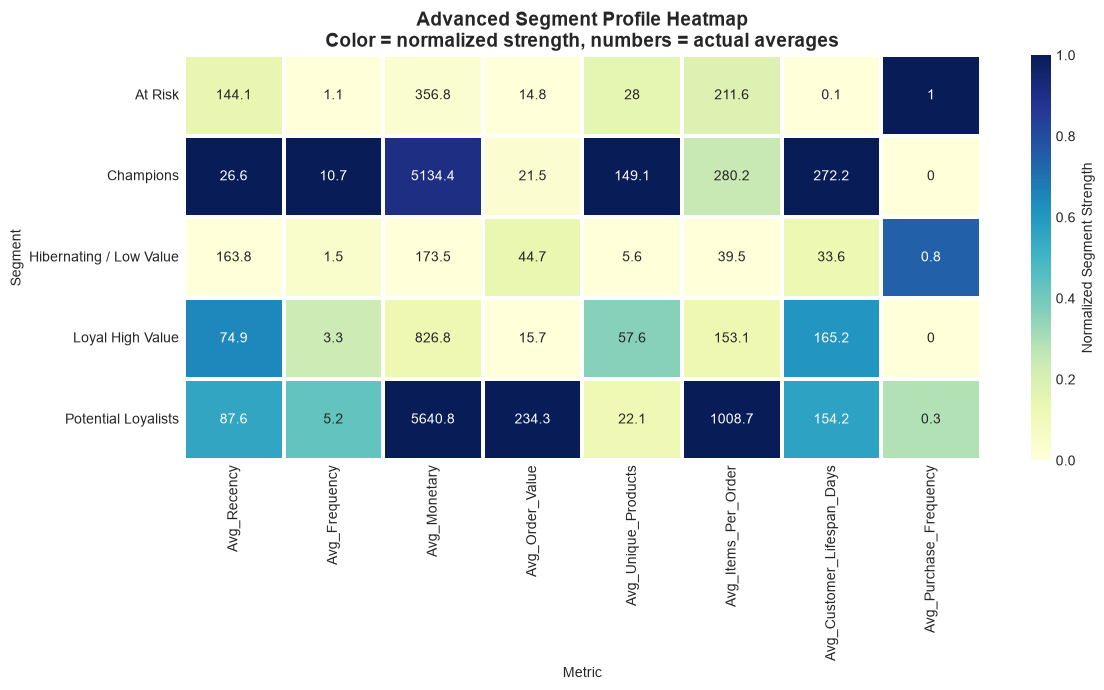

In [17]:
heatmap_cols = [
    'Avg_Recency',
    'Avg_Frequency',
    'Avg_Monetary',
    'Avg_Order_Value',
    'Avg_Unique_Products',
    'Avg_Items_Per_Order',
    'Avg_Customer_Lifespan_Days',
    'Avg_Purchase_Frequency',
]

heatmap_cols = [col for col in heatmap_cols if col in advanced_segment_profile.columns]

heatmap_data = advanced_segment_profile[heatmap_cols].copy()

normalized_heatmap = (
    heatmap_data - heatmap_data.min()
) / (
    heatmap_data.max() - heatmap_data.min()
).replace(0, 1)

# For Recency, lower is better, so invert it for the color scale.
if 'Avg_Recency' in normalized_heatmap.columns:
    normalized_heatmap['Avg_Recency'] = 1 - normalized_heatmap['Avg_Recency']

plt.figure(figsize=(12, 7))
sns.heatmap(
    normalized_heatmap,
    annot=heatmap_data.round(1),
    fmt='g',
    cmap='YlGnBu',
    linewidths=1.5,
    cbar_kws={'label': 'Normalized Segment Strength'},
    annot_kws={'size': 10},
)

plt.title(
    'Advanced Segment Profile Heatmap\nColor = normalized strength, numbers = actual averages',
    fontweight='bold',
    fontsize=14,
)
plt.xlabel('Metric')
plt.ylabel('Segment')
plt.tight_layout()
plt.savefig('../reports/figures/advanced_segment_profile_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

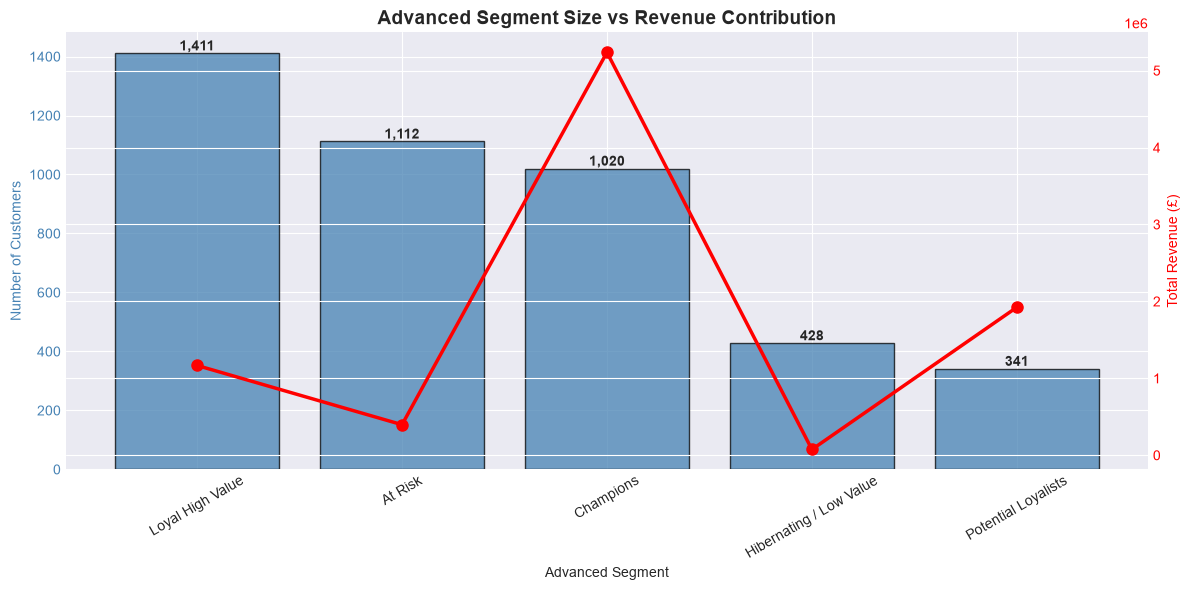

In [18]:
profile_sorted = advanced_segment_profile.sort_values('Count', ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))

segments = profile_sorted.index.astype(str)
counts = profile_sorted['Count']

bars = ax1.bar(
    segments,
    counts,
    color='steelblue',
    alpha=0.75,
    edgecolor='black',
    label='Customer Count',
)

ax1.set_xlabel('Advanced Segment')
ax1.set_ylabel('Number of Customers', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.tick_params(axis='x', rotation=30)

for bar, count in zip(bars, counts):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{int(count):,}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
    )

if 'Total_Revenue' in profile_sorted.columns:
    ax2 = ax1.twinx()
    revenue = profile_sorted['Total_Revenue']

    ax2.plot(
        segments,
        revenue,
        color='red',
        marker='o',
        linewidth=2.5,
        markersize=8,
        label='Total Revenue',
    )

    ax2.set_ylabel('Total Revenue (£)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

plt.title('Advanced Segment Size vs Revenue Contribution', fontweight='bold', fontsize=14)
fig.tight_layout()
plt.savefig('../reports/figures/advanced_segment_size_revenue.png', dpi=300, bbox_inches='tight')
plt.show()

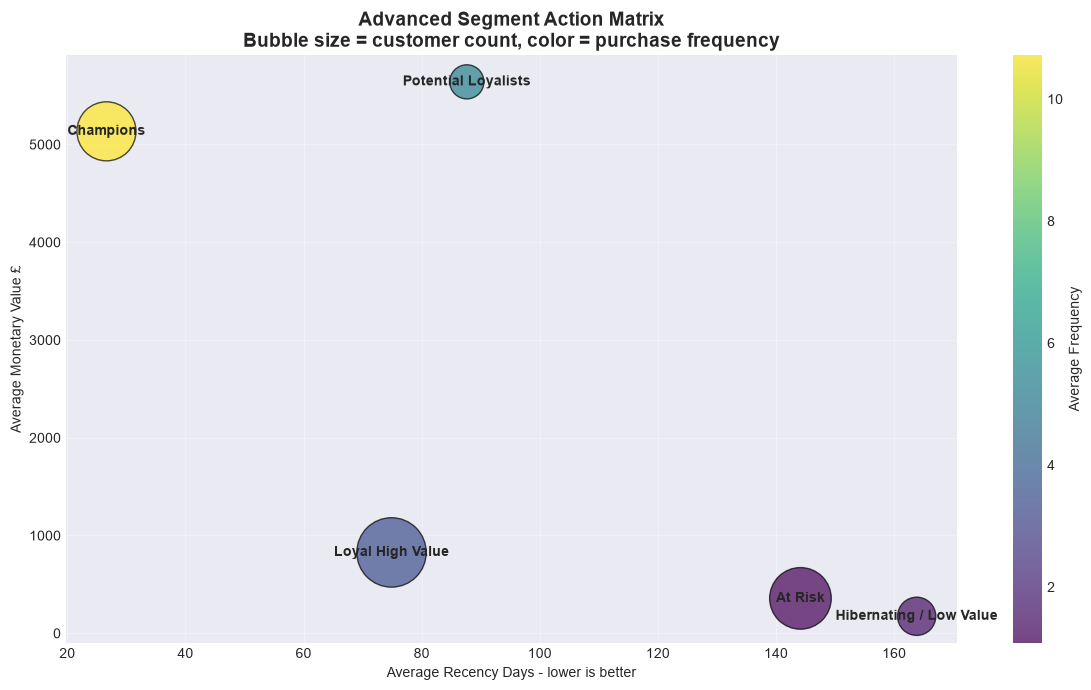

In [19]:
if all(col in advanced_segment_profile.columns for col in ['Avg_Recency', 'Avg_Monetary', 'Avg_Frequency']):
    plt.figure(figsize=(12, 7))

    sizes = advanced_segment_profile['Count'] / advanced_segment_profile['Count'].max() * 2500

    scatter = plt.scatter(
        advanced_segment_profile['Avg_Recency'],
        advanced_segment_profile['Avg_Monetary'],
        s=sizes,
        c=advanced_segment_profile['Avg_Frequency'],
        cmap='viridis',
        alpha=0.7,
        edgecolors='black',
        linewidth=1,
    )

    for segment, row in advanced_segment_profile.iterrows():
        plt.text(
            row['Avg_Recency'],
            row['Avg_Monetary'],
            str(segment),
            fontsize=10,
            ha='center',
            va='center',
            fontweight='bold',
        )

    cbar = plt.colorbar(scatter)
    cbar.set_label('Average Frequency')

    plt.xlabel('Average Recency Days - lower is better')
    plt.ylabel('Average Monetary Value £')
    plt.title(
        'Advanced Segment Action Matrix\nBubble size = customer count, color = purchase frequency',
        fontweight='bold',
        fontsize=14,
    )
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('../reports/figures/advanced_segment_action_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Skipping action matrix because required RFM columns are missing.")


In [20]:
strategy_map = {
    'Champions': {
        'profile': 'Best customers with recent purchases, high frequency, and high value.',
        'goal': 'Retain and reward.',
        'actions': [
            'VIP loyalty rewards',
            'Early access to new products',
            'Premium bundles',
            'Referral incentives',
        ],
    },
    'Loyal High Value': {
        'profile': 'Strong repeat buyers with meaningful revenue contribution.',
        'goal': 'Increase basket size and keep engagement high.',
        'actions': [
            'Cross-sell related categories',
            'Personalized recommendations',
            'Tiered discounts',
            'Subscription or membership offers',
        ],
    },
    'Potential Loyalists': {
        'profile': 'Promising customers who can become high-value with nurturing.',
        'goal': 'Increase repeat purchase frequency.',
        'actions': [
            'Second-purchase campaigns',
            'Product education emails',
            'Limited-time incentives',
            'Personalized product suggestions',
        ],
    },
    'At Risk': {
        'profile': 'Previously valuable customers showing signs of inactivity.',
        'goal': 'Win back before churn.',
        'actions': [
            'Win-back email campaigns',
            'Personalized discount codes',
            'Reminder campaigns',
            'Feedback or satisfaction surveys',
        ],
    },
    'Hibernating / Low Value': {
        'profile': 'Low value and/or inactive customers.',
        'goal': 'Reactivate efficiently without overspending.',
        'actions': [
            'Low-cost automated reactivation',
            'Clearance promotions',
            'Preference collection',
            'Suppress from expensive paid campaigns',
        ],
    },
    'Occasional Buyers': {
        'profile': 'Customers who purchase infrequently.',
        'goal': 'Encourage more regular purchasing.',
        'actions': [
            'Seasonal campaigns',
            'Reminder emails',
            'Small basket incentives',
            'Category-based recommendations',
        ],
    },
    'Needs Attention': {
        'profile': 'Mixed-value customers requiring closer monitoring.',
        'goal': 'Identify next best action.',
        'actions': [
            'Behavior-based targeting',
            'A/B test incentives',
            'Personalized recommendations',
            'Engagement scoring',
        ],
    },
    'Low Value': {
        'profile': 'Lowest commercial value customers.',
        'goal': 'Automate and minimize acquisition/retention cost.',
        'actions': [
            'Automated newsletters',
            'Low-cost promotions',
            'Exclude from premium campaigns',
            'Monitor for organic reactivation',
        ],
    },
}

recommendations = []

for segment in advanced_segment_profile.index:
    strategy = strategy_map.get(segment, {
        'profile': 'Custom segment profile.',
        'goal': 'Monitor and optimize.',
        'actions': ['Analyze behavior', 'Test targeted offers'],
    })

    recommendations.append({
        'Segment': segment,
        'Customers': int(advanced_segment_profile.loc[segment, 'Count']),
        'Customer_Share_%': float(advanced_segment_profile.loc[segment, 'Customer_Share_%']),
        'Revenue_Share_%': float(advanced_segment_profile.loc[segment, 'Revenue_Share_%'])
            if 'Revenue_Share_%' in advanced_segment_profile.columns else np.nan,
        'Profile': strategy['profile'],
        'Business_Goal': strategy['goal'],
        'Recommended_Actions': '; '.join(strategy['actions']),
    })

recommendations_df = pd.DataFrame(recommendations)

print("Segment strategy recommendations:\n")
recommendations_df

Segment strategy recommendations:



,Segment,Customers,Customer_Share_%,Revenue_Share_%,Profile,Business_Goal,Recommended_Actions
0,At Risk,1112,25.80,4.50,Previously valuable customers showing signs of...,Win back before churn.,Win-back email campaigns; Personalized discoun...
1,Champions,1020,23.70,59.50,"Best customers with recent purchases, high fre...",Retain and reward.,VIP loyalty rewards; Early access to new produ...
2,Hibernating / Low Value,428,9.90,0.80,Low value and/or inactive customers.,Reactivate efficiently without overspending.,Low-cost automated reactivation; Clearance pro...
3,Loyal High Value,1411,32.70,13.30,Strong repeat buyers with meaningful revenue c...,Increase basket size and keep engagement high.,Cross-sell related categories; Personalized re...
4,Potential Loyalists,341,7.90,21.90,Promising customers who can become high-value ...,Increase repeat purchase frequency.,Second-purchase campaigns; Product education e...


In [21]:
customer_advanced.to_csv('../data/processed/customer_segments_advanced.csv', index=False)
advanced_cluster_profile.to_csv('../data/processed/advanced_cluster_profiles.csv')
advanced_segment_profile.to_csv('../data/processed/advanced_segment_profiles.csv')
recommendations_df.to_csv('../data/processed/segment_recommendations.csv', index=False)

joblib.dump(final_model, '../models/advanced_kmeans_model.pkl')
joblib.dump(advanced_clusterer.scaler, '../models/advanced_scaler.pkl')

advanced_config = {
    'algorithm': FINAL_ALGORITHM,
    'n_clusters': FINAL_K,
    'feature_cols': feature_cols,
    'log_transform_cols': log_transform_cols,
    'scaler_type': advanced_clusterer.scaler_type,
    'business_labels': {
        str(k): v for k, v in advanced_cluster_labels.items()
    },
}

joblib.dump(advanced_config, '../models/advanced_clustering_config.pkl')

print("Saved processed data:")
print("  - data/processed/customer_segments_advanced.csv")
print("  - data/processed/advanced_cluster_profiles.csv")
print("  - data/processed/advanced_segment_profiles.csv")
print("  - data/processed/segment_recommendations.csv")
print("  - data/processed/advanced_clustering_comparison.csv")

print("\nSaved models:")
print("  - models/advanced_kmeans_model.pkl")
print("  - models/advanced_scaler.pkl")
print("  - models/advanced_clustering_config.pkl")

Saved processed data:
  - data/processed/customer_segments_advanced.csv
  - data/processed/advanced_cluster_profiles.csv
  - data/processed/advanced_segment_profiles.csv
  - data/processed/segment_recommendations.csv
  - data/processed/advanced_clustering_comparison.csv

Saved models:
  - models/advanced_kmeans_model.pkl
  - models/advanced_scaler.pkl
  - models/advanced_clustering_config.pkl


In [22]:
def safe_float(value):
    if pd.isna(value):
        return None
    return float(value)

advanced_summary = {
    'analysis_date': pd.Timestamp.now().isoformat(),
    'algorithm': FINAL_ALGORITHM,
    'n_clusters': int(FINAL_K),
    'features_used': feature_cols,
    'log_transform_cols': log_transform_cols,
    'scaler_type': advanced_clusterer.scaler_type,
    'total_customers': int(len(customer_advanced)),
    'model_metrics': {
        key: safe_float(value) if isinstance(value, float) else int(value)
        for key, value in final_metrics.items()
    },
    'segments': {},
}

for segment, row in advanced_segment_profile.iterrows():
    advanced_summary['segments'][str(segment)] = {
        'count': int(row['Count']),
        'customer_share_pct': safe_float(row['Customer_Share_%']),
        'revenue_share_pct': safe_float(row['Revenue_Share_%'])
            if 'Revenue_Share_%' in row else None,
        'avg_recency': safe_float(row['Avg_Recency'])
            if 'Avg_Recency' in row else None,
        'avg_frequency': safe_float(row['Avg_Frequency'])
            if 'Avg_Frequency' in row else None,
        'avg_monetary': safe_float(row['Avg_Monetary'])
            if 'Avg_Monetary' in row else None,
        'total_revenue': safe_float(row['Total_Revenue'])
            if 'Total_Revenue' in row else None,
    }

advanced_summary['recommendations'] = recommendations_df.to_dict(orient='records')

with open('../reports/advanced_clustering_summary.json', 'w') as f:
    json.dump(advanced_summary, f, indent=4)

print("Advanced clustering summary saved to:")
print("  - reports/advanced_clustering_summary.json")

Advanced clustering summary saved to:
  - reports/advanced_clustering_summary.json


In [23]:
print("=" * 65)
print("ADVANCED CLUSTERING & SEGMENT PROFILING SUMMARY")
print("=" * 65)

print(f"\nCustomers analyzed:      {len(customer_advanced):,}")
print(f"Algorithm selected:      {FINAL_ALGORITHM}")
print(f"Number of segments:      {FINAL_K}")
print(f"Features used:           {len(feature_cols)}")
print(f"Scaler:                  {advanced_clusterer.scaler_type}")

print("\nModel quality:")
for key, value in final_metrics.items():
    if isinstance(value, float):
        print(f"  {key:22s}: {value:.3f}")
    else:
        print(f"  {key:22s}: {value}")

print("\nAdvanced segments:")
for segment, row in advanced_segment_profile.iterrows():
    rev_share = row['Revenue_Share_%'] if 'Revenue_Share_%' in row else 0

    print(
        f"  {segment:25s} "
        f"{int(row['Count']):>5,} customers "
        f"({row['Customer_Share_%']:>5.1f}% customers, "
        f"{rev_share:>5.1f}% revenue)"
    )

print("\nFiles created:")
print("  - customer_segments_advanced.csv")
print("  - advanced_cluster_profiles.csv")
print("  - advanced_segment_profiles.csv")
print("  - segment_recommendations.csv")
print("  - advanced_clustering_comparison.csv")
print("  - advanced_clustering_summary.json")
print("  - advanced_kmeans_model.pkl")
print("  - advanced_scaler.pkl")
print("  - advanced_clustering_config.pkl")
print("  - 5+ advanced visualization plots")

print("\nReady for Part 7: Customer Segment Dashboard / Reporting!")
print("=" * 65)

ADVANCED CLUSTERING & SEGMENT PROFILING SUMMARY

Customers analyzed:      4,312
Algorithm selected:      kmeans
Number of segments:      5
Features used:           8
Scaler:                  robust

Model quality:
  n_clusters            : 5
  n_noise               : 0
  silhouette            : 0.218
  calinski_harabasz     : 1249.862
  davies_bouldin        : 1.358
  min_cluster_size      : 341
  min_cluster_pct       : 7.908

Advanced segments:
  At Risk                   1,112 customers ( 25.8% customers,   4.5% revenue)
  Champions                 1,020 customers ( 23.7% customers,  59.5% revenue)
  Hibernating / Low Value     428 customers (  9.9% customers,   0.8% revenue)
  Loyal High Value          1,411 customers ( 32.7% customers,  13.3% revenue)
  Potential Loyalists         341 customers (  7.9% customers,  21.9% revenue)

Files created:
  - customer_segments_advanced.csv
  - advanced_cluster_profiles.csv
  - advanced_segment_profiles.csv
  - segment_recommendations.csv
  -